In [177]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

In [178]:
data = pd.read_csv('uci-secom.csv')

In [179]:
data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [180]:
data.size

927664

In [181]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


In [182]:
data.shape

(1567, 592)

In [183]:
data.isnull().sum()

,0
Time,0
0,6
1,7
2,14
3,14
...,...
586,1
587,1
588,1
589,1


# **Separating Time, 0-589 features, Pass/Fail**

In [184]:
time_col = data["Time"]
X = data.iloc[:, 0:590]
y = data["Pass/Fail"]

In [185]:
class_count = y.value_counts()
class_count

,count
Pass/Fail,
-1,1463
1,104


In [186]:
class_percentage = y.value_counts(normalize=True) * 100
class_percentage

,proportion
Pass/Fail,
-1,93.363114
1,6.636886


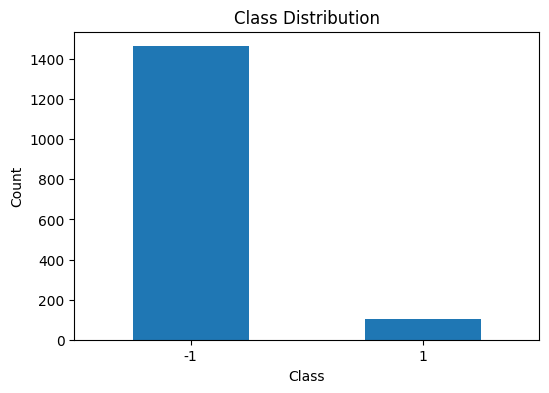

In [187]:
plt.figure(figsize=(6,4))
class_count.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(rotation=0)
plt.show()

# **Remapping Labels of Pass/Fail**

In [188]:
y = y.map({
    -1: 0,
    1: 1
})

# **Missing Values**

In [189]:
X.isnull().sum().sum()

np.int64(41950)

In [190]:
X.isnull().mean().mean() * 100

np.float64(4.537440645517181)

In [191]:
missing_pect = X.isnull().mean() * 100
missing_pect.sort_values(ascending=False).head(32)

,0
293,91.193363
292,91.193363
158,91.193363
157,91.193363
492,85.577537
220,85.577537
358,85.577537
85,85.577537
244,64.964901
109,64.964901


top 32 features were > 45%
and the rest features are < 17%

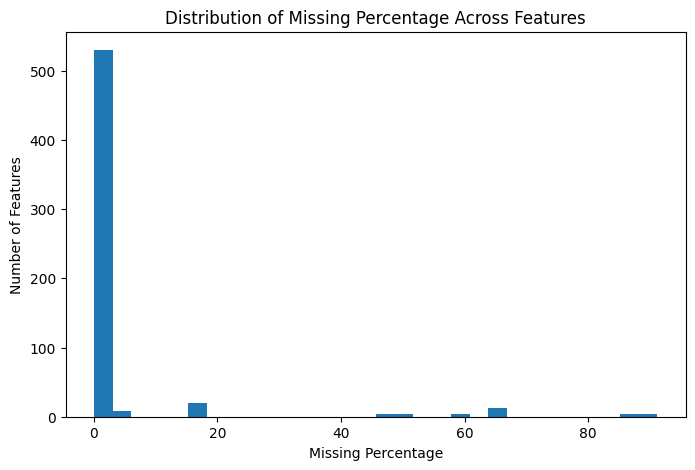

In [192]:
plt.figure(figsize=(8,5))
plt.hist(missing_pect, bins = 30)
plt.title("Distribution of Missing Percentage Across Features")
plt.xlabel("Missing Percentage")
plt.ylabel("Number of Features")

plt.show()

In [193]:
complete_cols = missing_pect[missing_pect == 0]
low_missing_cols = missing_pect[(missing_pect > 0) & (missing_pect <= 5)]
medium_missing_cols = missing_pect[(missing_pect > 5) & (missing_pect < 45)]
high_missing_cols = missing_pect[missing_pect >= 45]

print(f"Complete Columns: {len(complete_cols)}")
print(f"Low Missing Columns: {len(low_missing_cols)}")
print(f"Medium Missing Columns: {len(medium_missing_cols)}")
print(f"High Missing Columns: {len(high_missing_cols)}")

Complete Columns: 53
Low Missing Columns: 485
Medium Missing Columns: 20
High Missing Columns: 32


In [194]:
print(high_missing_cols.sort_values(ascending=False))

157    91.193363
292    91.193363
293    91.193363
158    91.193363
220    85.577537
85     85.577537
492    85.577537
358    85.577537
245    64.964901
244    64.964901
246    64.964901
111    64.964901
382    64.964901
383    64.964901
110    64.964901
109    64.964901
384    64.964901
518    64.964901
517    64.964901
516    64.964901
580    60.561583
579    60.561583
581    60.561583
578    60.561583
346    50.670070
345    50.670070
72     50.670070
73     50.670070
247    45.628590
112    45.628590
385    45.628590
519    45.628590
dtype: float64


In [195]:
missing_per_row = X.isnull().sum(axis=1)

print("Per-row Missingness Statistics:")
print(missing_per_row.describe())

high_missing_rows = missing_per_row[missing_per_row > missing_per_row.quantile(0.99)]

print("\nRows with unusually high missing values:")
print(high_missing_rows)

Per-row Missingness Statistics:
count    1567.000000
mean       26.770900
std        13.376719
min         4.000000
25%        20.000000
50%        24.000000
75%        32.000000
max       152.000000
dtype: float64

Rows with unusually high missing values:
89       87
93       96
95       96
511     100
735      88
810      99
814      96
995      92
1054     92
1152    100
1561    140
1564    148
1566    152
dtype: int64


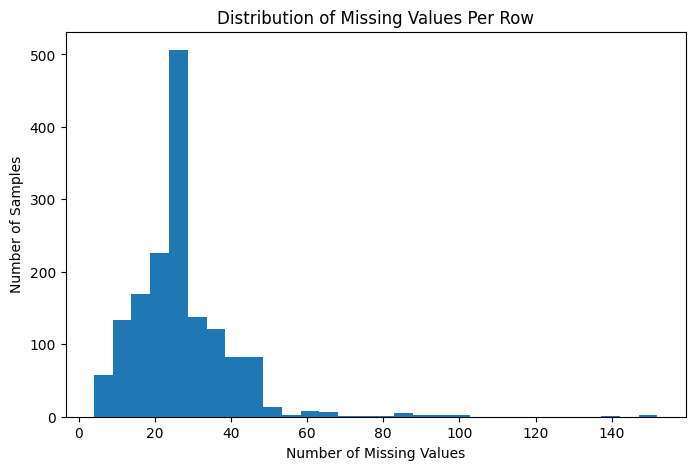

In [196]:
plt.figure(figsize=(8, 5))

plt.hist(missing_per_row, bins=30)

plt.title("Distribution of Missing Values Per Row")
plt.xlabel("Number of Missing Values")
plt.ylabel("Number of Samples")

plt.show()

In [197]:
row_missing_rate = X.isnull().mean(axis=1) * 100

missingness_by_class = pd.DataFrame({
    "Target": y,
    "MissingRate": row_missing_rate
})

avg_missing_by_class = missingness_by_class.groupby("Target")["MissingRate"].mean()

print("Average Missingness Rate by Class:\n")
print(avg_missing_by_class)

Average Missingness Rate by Class:

Target
0    4.553217
1    4.315515
Name: MissingRate, dtype: float64


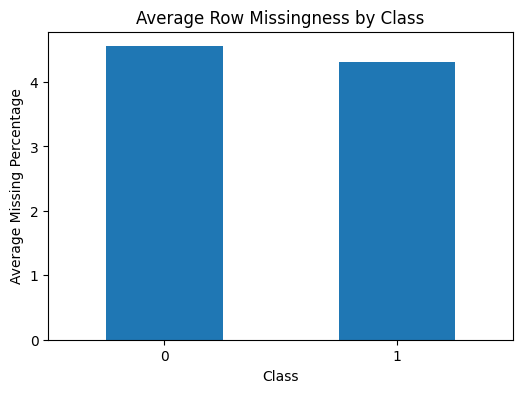

In [198]:
plt.figure(figsize=(6, 4))

avg_missing_by_class.plot(kind='bar')
plt.title("Average Row Missingness by Class")
plt.xlabel("Class")
plt.ylabel("Average Missing Percentage")
plt.xticks(rotation=0)

plt.show()

# **Identifying Constant columns**

In [199]:
std_per_col = X.select_dtypes(include=np.number).std()

zero_variance_cols = std_per_col[std_per_col == 0].index.tolist()

print("Number of Zero-Variance Columns:", len(zero_variance_cols))

print("\nZero-Variance Columns:", zero_variance_cols)

Number of Zero-Variance Columns: 116

Zero-Variance Columns: ['5', '13', '42', '49', '52', '69', '97', '141', '149', '178', '179', '186', '189', '190', '191', '192', '193', '194', '226', '229', '230', '231', '232', '233', '234', '235', '236', '237', '240', '241', '242', '243', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '276', '284', '313', '314', '315', '322', '325', '326', '327', '328', '329', '330', '364', '369', '370', '371', '372', '373', '374', '375', '378', '379', '380', '381', '394', '395', '396', '397', '398', '399', '400', '401', '402', '403', '404', '414', '422', '449', '450', '451', '458', '461', '462', '463', '464', '465', '466', '481', '498', '501', '502', '503', '504', '505', '506', '507', '508', '509', '512', '513', '514', '515', '528', '529', '530', '531', '532', '533', '534', '535', '536', '537', '538']


# **Near-Zero variance analysis**

In [200]:
variance_per_col = X.select_dtypes(include=np.number).var()

nonzero_variances = variance_per_col[variance_per_col > 0]

low_variance_threshold = np.percentile(nonzero_variances, 1)

near_zero_variance_cols = variance_per_col[
    variance_per_col <= low_variance_threshold
].index.tolist()

print("Near-Zero Variance Threshold:", low_variance_threshold)

print("\nNumber of Near-Zero Variance Columns:")
print(len(near_zero_variance_cols))

print("\nNear-Zero Variance Columns:")
print(near_zero_variance_cols)

Near-Zero Variance Threshold: 1.2338702619950692e-07

Number of Near-Zero Variance Columns:
121

Near-Zero Variance Columns:
['5', '13', '42', '49', '52', '69', '94', '95', '97', '101', '141', '149', '178', '179', '186', '189', '190', '191', '192', '193', '194', '226', '229', '230', '231', '232', '233', '234', '235', '236', '237', '240', '241', '242', '243', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '276', '278', '284', '313', '314', '315', '322', '325', '326', '327', '328', '329', '330', '364', '369', '370', '371', '372', '373', '374', '375', '378', '379', '380', '381', '394', '395', '396', '397', '398', '399', '400', '401', '402', '403', '404', '414', '422', '449', '450', '451', '458', '461', '462', '463', '464', '465', '466', '481', '498', '501', '502', '503', '504', '505', '506', '507', '508', '509', '512', '513', '514', '515', '528', '529', '530', '531', '532', '533', '534', '535', '536', '537', '538', '544']


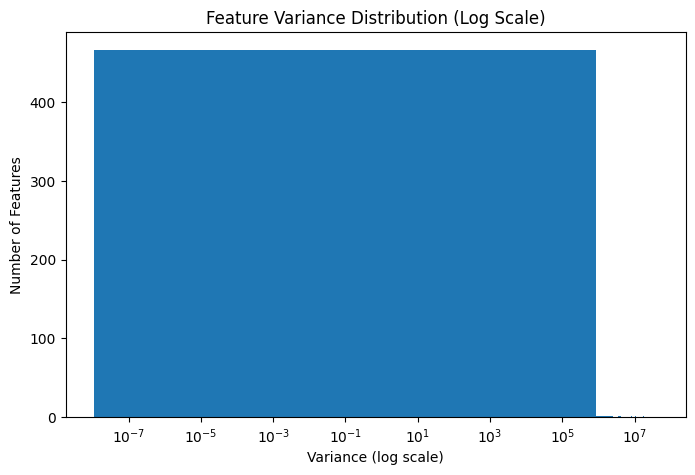

In [201]:
plt.figure(figsize=(8, 5))

plt.hist(nonzero_variances, bins=50)

plt.xscale('log')

plt.title("Feature Variance Distribution (Log Scale)")
plt.xlabel("Variance (log scale)")
plt.ylabel("Number of Features")

plt.show()

# **Drop Problematic Column**

In [202]:
high_missing_cols_list = high_missing_cols.index.tolist()

cols_to_drop = list(
    set(zero_variance_cols + high_missing_cols_list)
)

X_clean = X.drop(columns=cols_to_drop)

print("Original Shape:", X.shape)

print("\nDropped Columns:")
print(f"- Zero-Variance Columns: {len(zero_variance_cols)}")
print(f"- >50% Missing Columns: {len(high_missing_cols_list)}")

print(f"\nTotal Unique Columns Dropped: {len(cols_to_drop)}")

print("\nCleaned Shape:", X_clean.shape)

Original Shape: (1567, 590)

Dropped Columns:
- Zero-Variance Columns: 116
- >50% Missing Columns: 32

Total Unique Columns Dropped: 148

Cleaned Shape: (1567, 442)


# **Univariate Distribution Analysis**

In [203]:
desc_stats = X_clean.describe().T

print(desc_stats.head())

print("\nColumns with Largest Standard Deviations:")
print(desc_stats["std"].sort_values(ascending=False).head(10))

print("\nColumns with Smallest Minimum Values:")
print(desc_stats["min"].sort_values().head(10))

print("\nColumns with Largest Maximum Values:")
print(desc_stats["max"].sort_values(ascending=False).head(10))

    count         mean         std        min        25%        50%  \
0  1561.0  3014.452896   73.621787  2743.2400  2966.2600  3011.4900   
1  1560.0  2495.850231   80.407705  2158.7500  2452.2475  2499.4050   
2  1553.0  2200.547318   29.513152  2060.6600  2181.0444  2201.0667   
3  1553.0  1396.376627  441.691640     0.0000  1081.8758  1285.2144   
4  1553.0     4.197013   56.355540     0.6815     1.0177     1.3168   

         75%        max  
0  3056.6500  3356.3500  
1  2538.8225  2846.4400  
2  2218.0555  2315.2667  
3  1591.2235  3715.0417  
4     1.5257  1114.5366  

Columns with Largest Standard Deviations:
162    6553.569317
161    4239.245058
297    3226.924298
24     2902.690117
296    1975.111365
23     1380.162148
159     983.043021
21      626.822178
160     574.808588
204     565.101239
Name: std, dtype: float64

Columns with Smallest Minimum Values:
24    -14804.5000
23     -9986.7500
21     -7150.2500
59       -28.9882
98        -5.2717
129       -3.7790
96        -

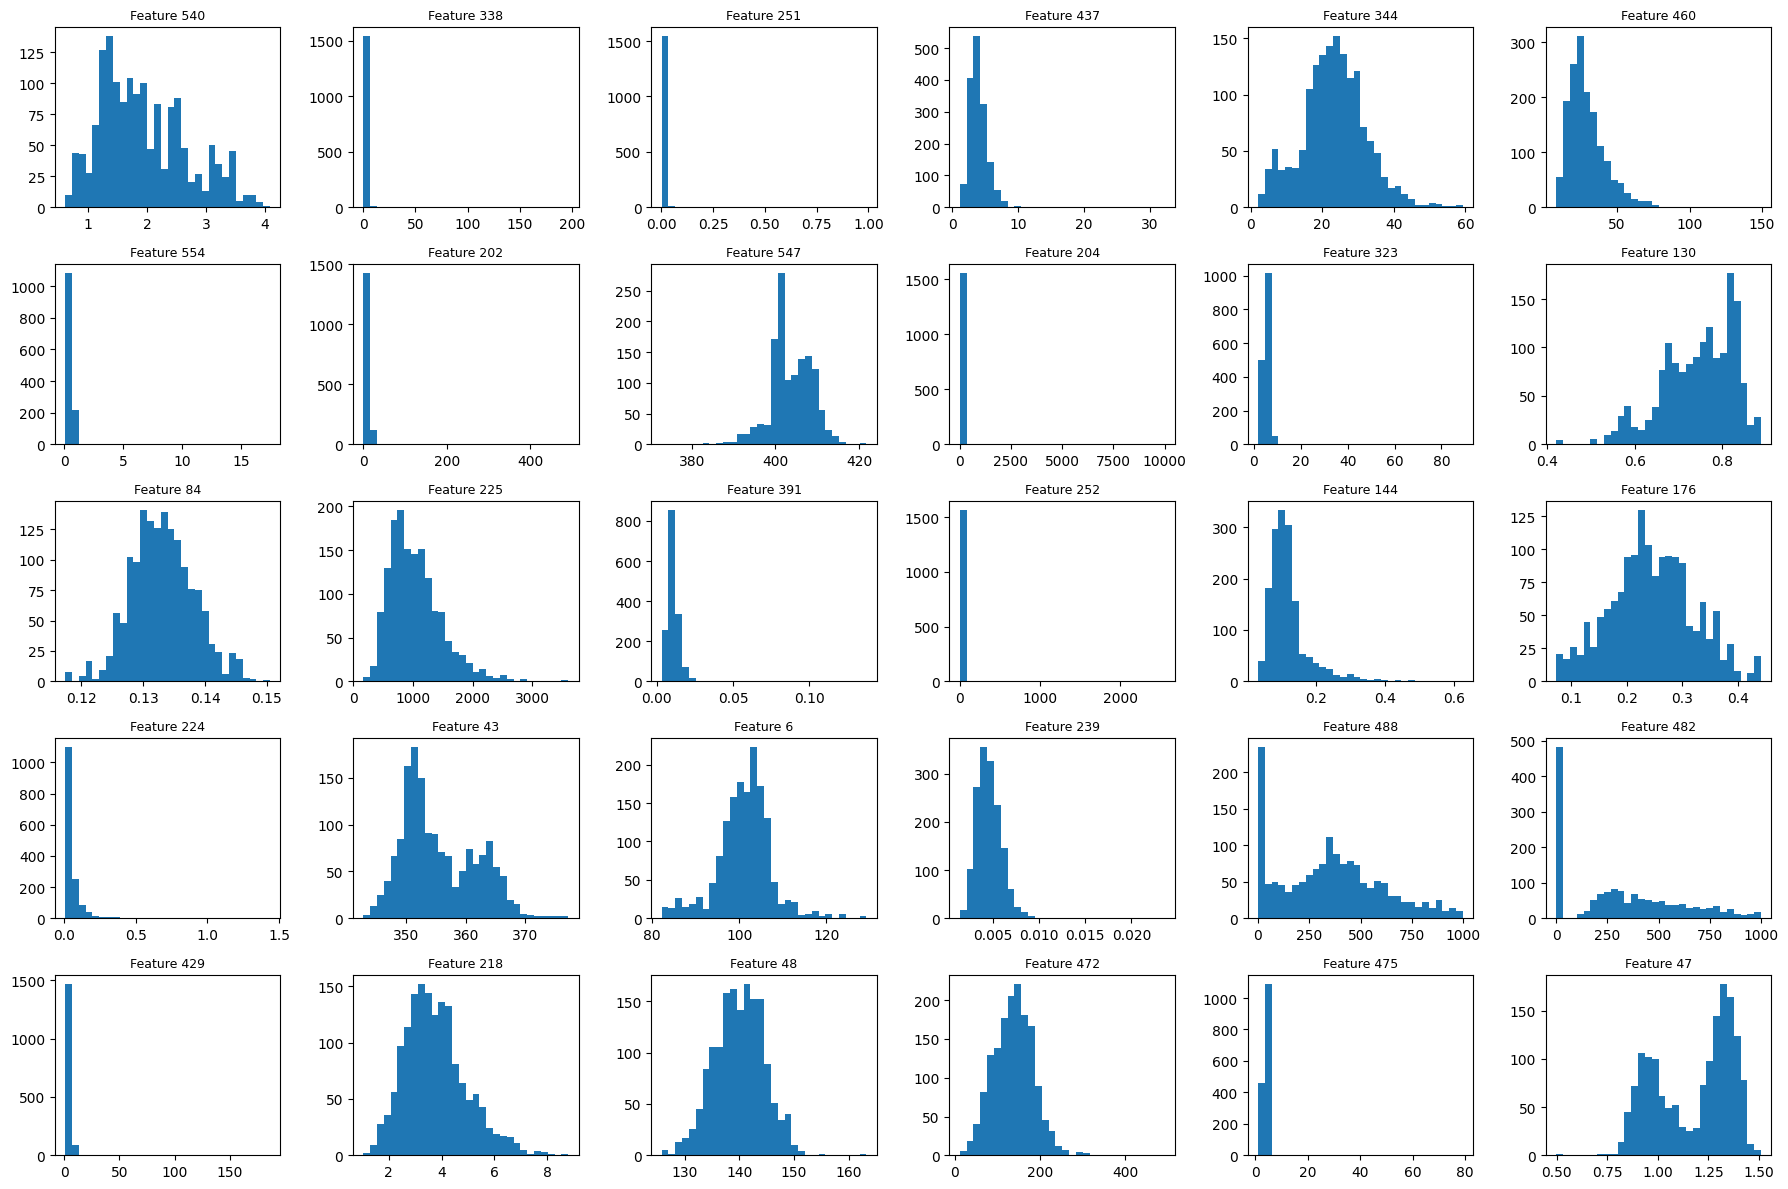

In [204]:
sample_cols = np.random.choice(X_clean.columns, 30, replace=False)

fig, axes = plt.subplots(5, 6, figsize=(18, 12))

axes = axes.flatten()


for i, col in enumerate(sample_cols):
    axes[i].hist(X_clean[col].dropna(), bins=30)
    axes[i].set_title(f"Feature {col}", fontsize=9)

plt.tight_layout()
plt.show()

# **Skewness Analysis**

In [205]:
skewness = X_clean.select_dtypes(include=np.number).skew()

high_skew_count = (skewness.abs() > 1).sum()
extreme_skew_count = (skewness.abs() > 2).sum()

print("Highly Skewed Features (|skew| > 1):", high_skew_count)
print("Extremely Skewed Features (|skew| > 2):", extreme_skew_count)

Highly Skewed Features (|skew| > 1): 293
Extremely Skewed Features (|skew| > 2): 243


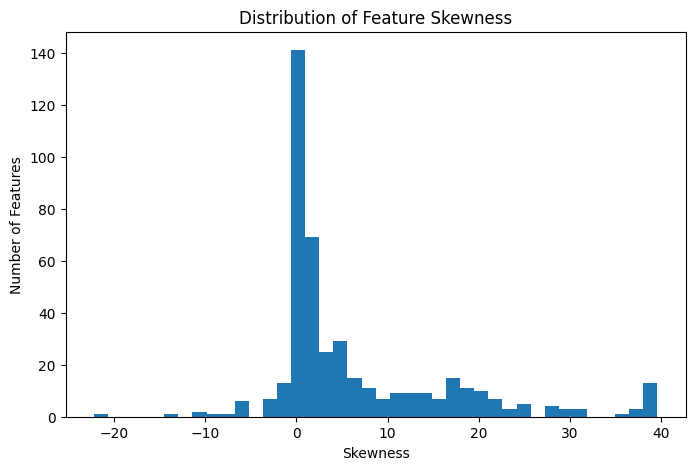

In [206]:
plt.figure(figsize=(8, 5))

plt.hist(skewness.dropna(), bins=40)

plt.title("Distribution of Feature Skewness")
plt.xlabel("Skewness")
plt.ylabel("Number of Features")

plt.show()

# **Kurtosis Analysis**

In [207]:
kurtosis_vals = X_clean.select_dtypes(include=np.number).kurtosis()

print("Top 10 Features with Highest Kurtosis:\n")

print(kurtosis_vals.sort_values(ascending=False).head(10))

Top 10 Features with Highest Kurtosis:

390    1565.804998
252    1565.677095
287    1562.619777
152    1562.528774
74     1561.000000
342    1561.000000
209    1561.000000
206    1561.000000
478    1561.000000
347    1561.000000
dtype: float64


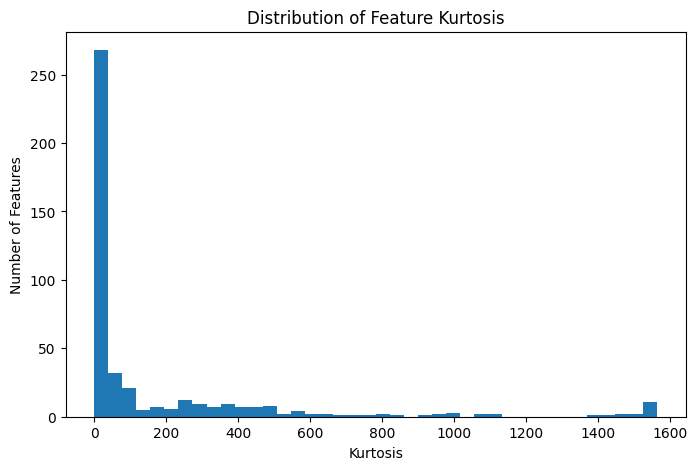

In [208]:
plt.figure(figsize=(8, 5))

plt.hist(kurtosis_vals.dropna(), bins=40)

plt.title("Distribution of Feature Kurtosis")
plt.xlabel("Kurtosis")
plt.ylabel("Number of Features")

plt.show()

# **Outlier Analysis**

In [209]:
outlier_fraction = {}

for col in X_clean.select_dtypes(include=np.number).columns:

    series = X_clean[col].dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    outlier_fraction[col] = len(outliers) / len(series) if len(series) > 0 else 0

outlier_fraction = pd.Series(outlier_fraction)

top_outlier_cols = outlier_fraction.sort_values(ascending=False).head(10)

print("Top 10 Columns with Highest Outlier Fraction:\n")
print(top_outlier_cols)

Top 10 Columns with Highest Outlier Fraction:

31     0.226198
40     0.213869
562    0.166151
129    0.152760
544    0.152716
312    0.149425
195    0.149072
448    0.146871
177    0.146871
467    0.139475
dtype: float64


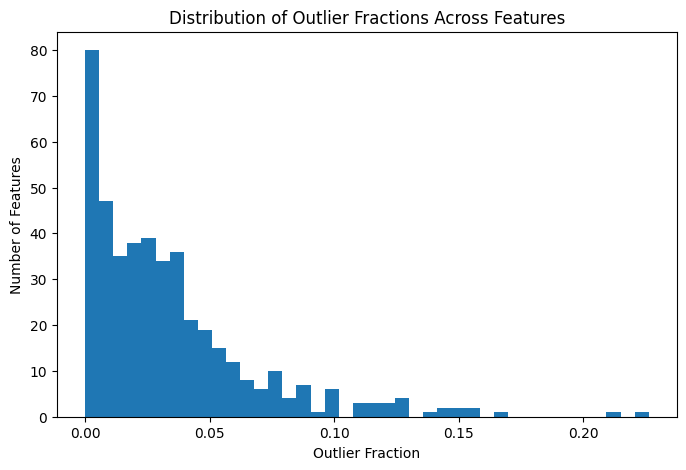

In [210]:
plt.figure(figsize=(8, 5))

plt.hist(outlier_fraction, bins=40)

plt.title("Distribution of Outlier Fractions Across Features")
plt.xlabel("Outlier Fraction")
plt.ylabel("Number of Features")

plt.show()

In [211]:
from scipy.stats import zscore

sample_cols = top_outlier_cols.index[:3]

for col in sample_cols:

    print(f"\n===== Feature: {col} =====")

    series = X_clean[col]

    valid_series = series.dropna()

    Q1 = valid_series.quantile(0.25)
    Q3 = valid_series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    iqr_outliers = valid_series[
        (valid_series < lower_bound) |
        (valid_series > upper_bound)
    ].index

    z_scores = np.abs(zscore(valid_series))

    z_outliers = valid_series[
        z_scores > 3
    ].index

    common_outliers = set(iqr_outliers).intersection(set(z_outliers))

    print("IQR Outliers:", len(iqr_outliers))
    print("Z-score Outliers:", len(z_outliers))
    print("Common Outliers:", len(common_outliers))


===== Feature: 31 =====
IQR Outliers: 354
Z-score Outliers: 0
Common Outliers: 0

===== Feature: 40 =====
IQR Outliers: 330
Z-score Outliers: 0
Common Outliers: 0

===== Feature: 562 =====
IQR Outliers: 215
Z-score Outliers: 6
Common Outliers: 6


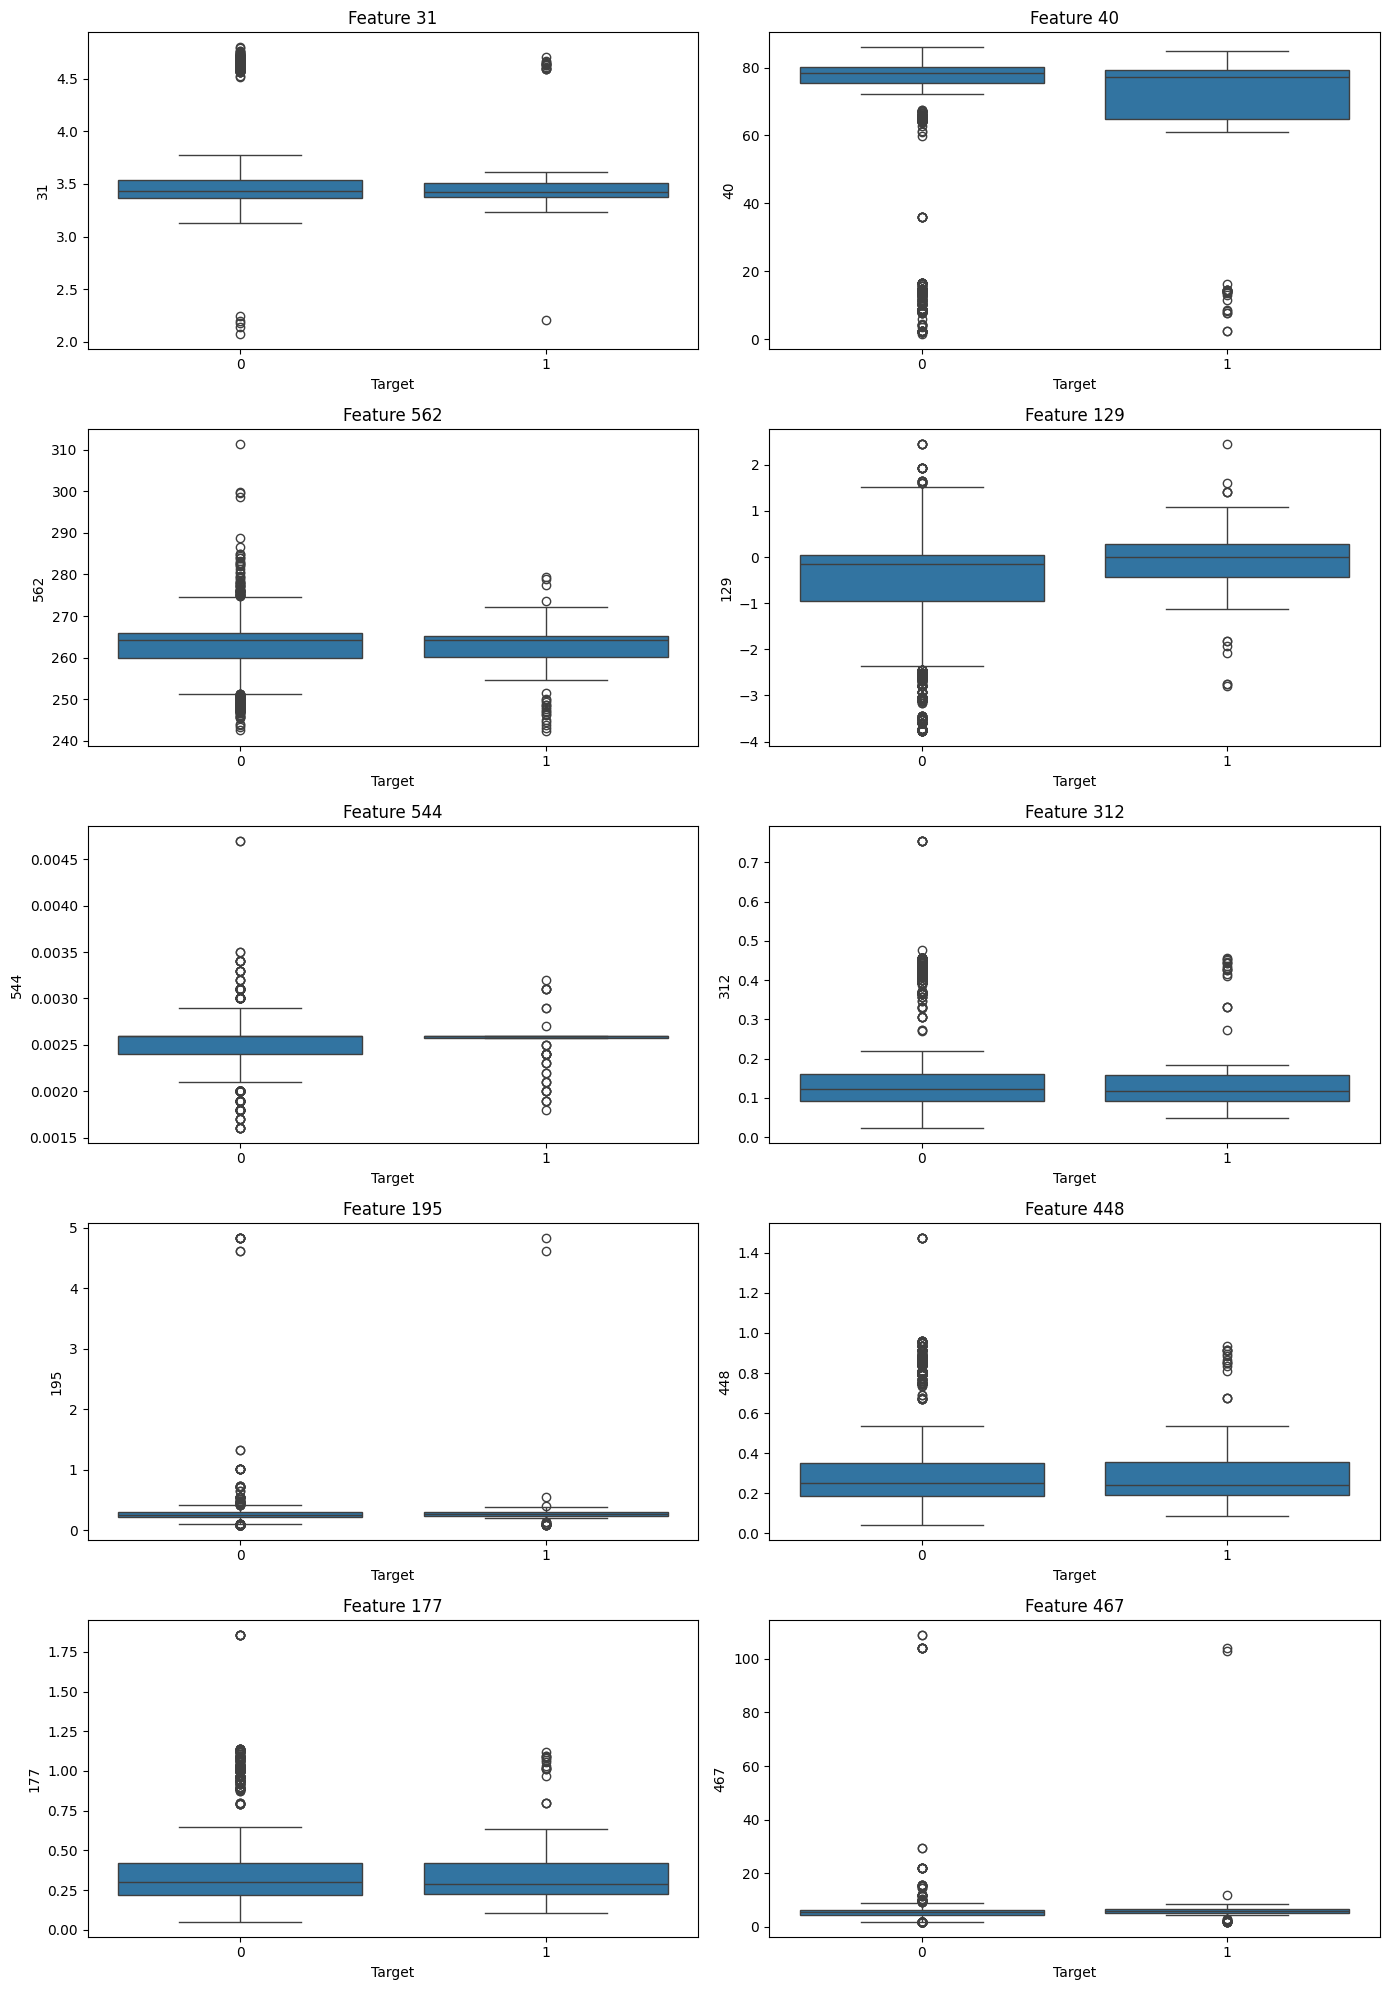

In [212]:
plot_df = X_clean.copy()
plot_df["Target"] = y

top10_cols = top_outlier_cols.index

fig, axes = plt.subplots(5, 2, figsize=(14, 20))

axes = axes.flatten()

for i, col in enumerate(top10_cols):

    sns.boxplot(
        x="Target",
        y=col,
        data=plot_df,
        ax=axes[i]
    )

    axes[i].set_title(f"Feature {col}")

plt.tight_layout()
plt.show()

# **Class-Separated Analysis**

In [213]:
class_means = X_clean.select_dtypes(include=np.number).groupby(y).mean().T

class_means.columns = ["Pass", "Fail"]

class_means["Mean_Difference"] = (
    class_means["Fail"] - class_means["Pass"]
)

class_means["Abs_Difference"] = (
    class_means["Mean_Difference"].abs()
)

mean_diff_ranked = class_means.sort_values(
    by="Abs_Difference",
    ascending=False
)

print("Top 10 Features by Mean Difference:\n")
print(mean_diff_ranked.head(10))

Top 10 Features by Mean Difference:

            Pass         Fail  Mean_Difference  Abs_Difference
161  4088.895349  3753.941748      -334.953601      334.953601
159   862.275650  1172.310680       310.035030      310.035030
21  -5636.437585 -5362.274272       274.163314      274.163314
24   -284.441518  -499.539641      -215.098123      215.098123
160   541.604651   750.398058       208.793407      208.793407
294   391.418291   549.383908       157.965617      157.965617
162  4807.294118  4653.233010      -154.061108      154.061108
296  1887.538118  1761.278333      -126.259785      126.259785
295   246.059016   351.508144       105.449128      105.449128
22   2705.158174  2617.339806       -87.818368       87.818368


In [214]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

X_pass = X_clean[y == 0]
X_fail = X_clean[y == 1]

results = []

for col in X_clean.select_dtypes(include=np.number).columns:

    pass_vals = X_pass[col].dropna()
    fail_vals = X_fail[col].dropna()

    if len(pass_vals) > 0 and len(fail_vals) > 0:
        stat, p_value = mannwhitneyu(
            pass_vals,
            fail_vals,
            alternative='two-sided'
        )

        results.append({
            "Feature": col,
            "P_Value": p_value
        })
    else:
        results.append({
            "Feature": col,
            "P_Value": np.nan
        })

pval_df = pd.DataFrame(results)

pval_df.dropna(subset=["P_Value"], inplace=True)

reject, corrected_pvals, _, _ = multipletests(
    pval_df["P_Value"],
    method='fdr_bh'
)

pval_df["Corrected_P"] = corrected_pvals
pval_df["Significant"] = reject

significant_count = pval_df["Significant"].sum()

print("Number of Statistically Significant Features:")
print(significant_count)

pval_df = pval_df.sort_values("Corrected_P")

print("\nTop 10 Most Significant Features:")
print(pval_df.head(10))

Number of Statistically Significant Features:
17

Top 10 Most Significant Features:
    Feature       P_Value   Corrected_P  Significant
54       59  5.678638e-11  2.504279e-08         True
93      103  9.550430e-09  2.105870e-06         True
385     510  3.452612e-06  5.075340e-04         True
364     477  3.500084e-05  3.551182e-03         True
115     129  4.831540e-05  3.551182e-03         True
178     205  4.717189e-05  3.551182e-03         True
26       28  6.955946e-05  4.382246e-03         True
31       33  1.613608e-04  8.410179e-03         True
270     341  1.869155e-04  8.410179e-03         True
252     316  1.907070e-04  8.410179e-03         True


In [215]:
volcano_df = pval_df.merge(
    mean_diff_ranked[["Mean_Difference"]],
    left_on="Feature",
    right_index=True
)

volcano_df["NegLog10P"] = -np.log10(volcano_df["Corrected_P"])

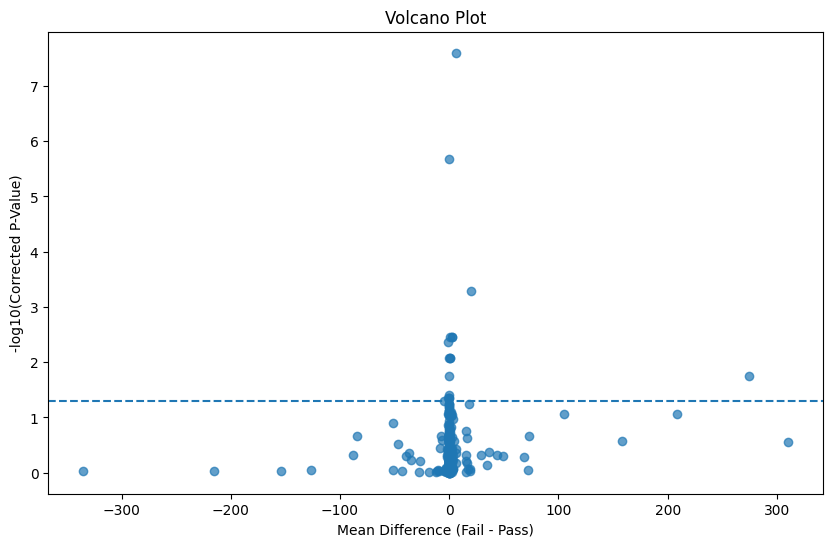

In [216]:
plt.figure(figsize=(10, 6))

plt.scatter(
    volcano_df["Mean_Difference"],
    volcano_df["NegLog10P"],
    alpha=0.7
)

plt.title("Volcano Plot")
plt.xlabel("Mean Difference (Fail - Pass)")
plt.ylabel("-log10(Corrected P-Value)")

plt.axhline(-np.log10(0.05), linestyle='--')

plt.show()

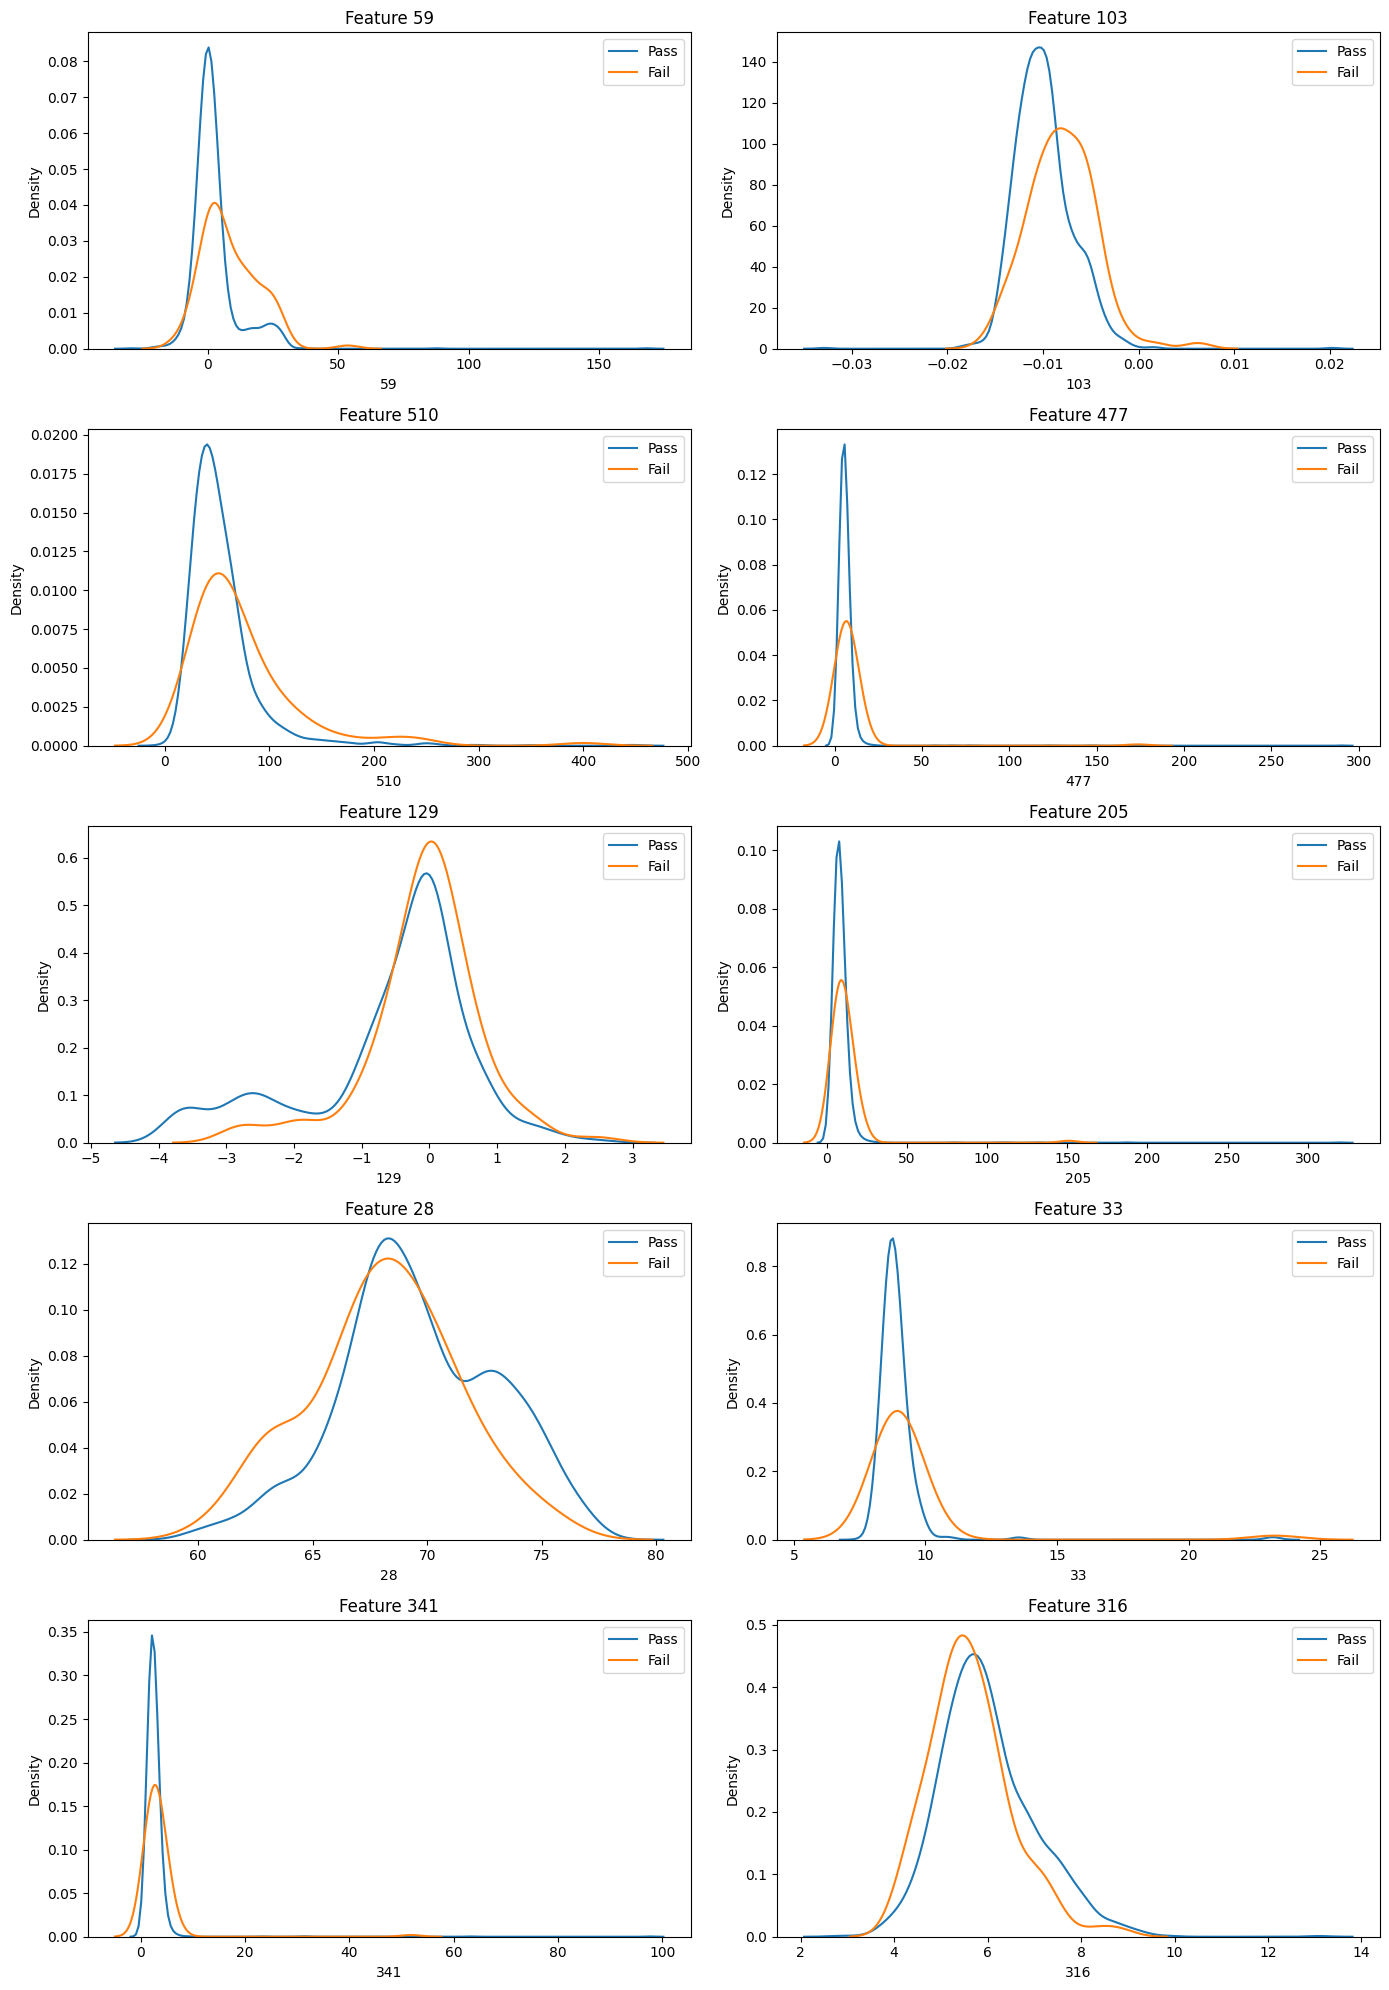

In [217]:
top_features = pval_df.head(10)["Feature"]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))

axes = axes.flatten()

for i, col in enumerate(top_features):

    sns.kdeplot(
        X_pass[col].dropna(),
        label="Pass",
        ax=axes[i]
    )

    sns.kdeplot(
        X_fail[col].dropna(),
        label="Fail",
        ax=axes[i]
    )

    axes[i].set_title(f"Feature {col}")
    axes[i].legend()

plt.tight_layout()
plt.show()

# **Correlation Analysis**

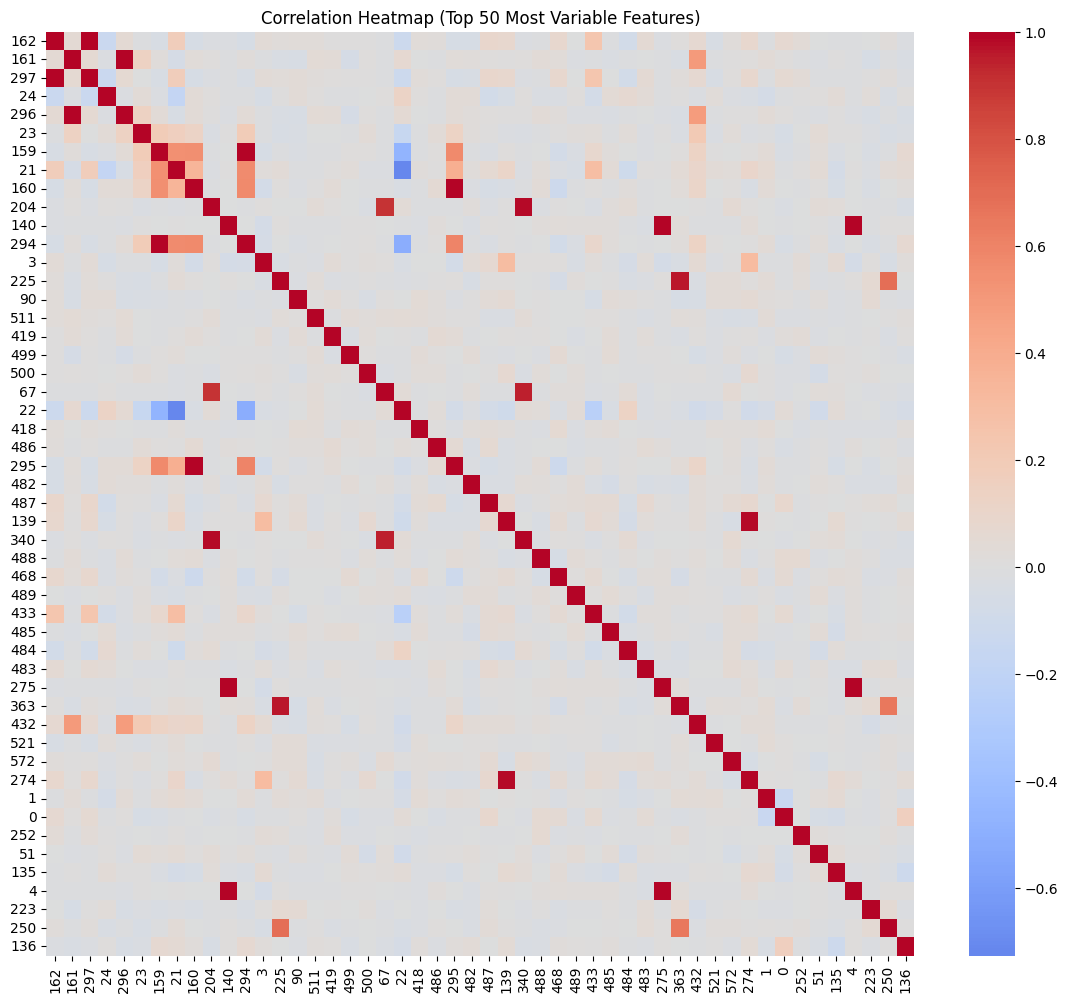

In [218]:
top_var_features = (
    X_clean.select_dtypes(include=np.number).var()
    .sort_values(ascending=False)
    .head(50)
    .index
)

corr_matrix = X_clean[top_var_features].corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap (Top 50 Most Variable Features)")

plt.show()

In [219]:
full_corr_matrix = X_clean.select_dtypes(include=np.number).corr().abs()

upper_triangle = full_corr_matrix.where(
    np.triu(np.ones(full_corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []

for col in upper_triangle.columns:

    high_corr = upper_triangle[col][upper_triangle[col] > 0.9]

    for idx, value in high_corr.items():

        high_corr_pairs.append(
            (idx, col, value)
        )

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature_1", "Feature_2", "Correlation"]
)

print("Number of Highly Correlated Pairs (|corr| > 0.9):")
print(len(high_corr_df))

print("\nTop Highly Correlated Pairs:")
print(high_corr_df.head(10))

Number of Highly Correlated Pairs (|corr| > 0.9):
349

Top Highly Correlated Pairs:
  Feature_1 Feature_2  Correlation
0         4         7     0.916410
1        25        27     0.980375
2        34        36     1.000000
3        46        50     0.904482
4        53        54     0.935221
5        43        60     0.900309
6        66        70     0.904461
7        94        96     0.957010
8        98       101     0.906788
9        99       104     0.990229


In [220]:
y_numeric = y

target_corr = X_clean.select_dtypes(include=np.number).corrwith(y_numeric)

target_corr_abs = target_corr.abs().sort_values(ascending=False)

top20_corr = target_corr_abs.head(20)

print("Top 20 Features Correlated with Target:\n")
print(top20_corr)

Top 20 Features Correlated with Target:

59     0.155796
103    0.151203
510    0.131593
348    0.130180
431    0.120851
434    0.112116
430    0.110067
435    0.109067
21     0.108488
28     0.107252
436    0.106910
129    0.103373
210    0.102545
298    0.102519
163    0.100330
124    0.093994
295    0.092249
160    0.090097
316    0.089412
164    0.088046
dtype: float64


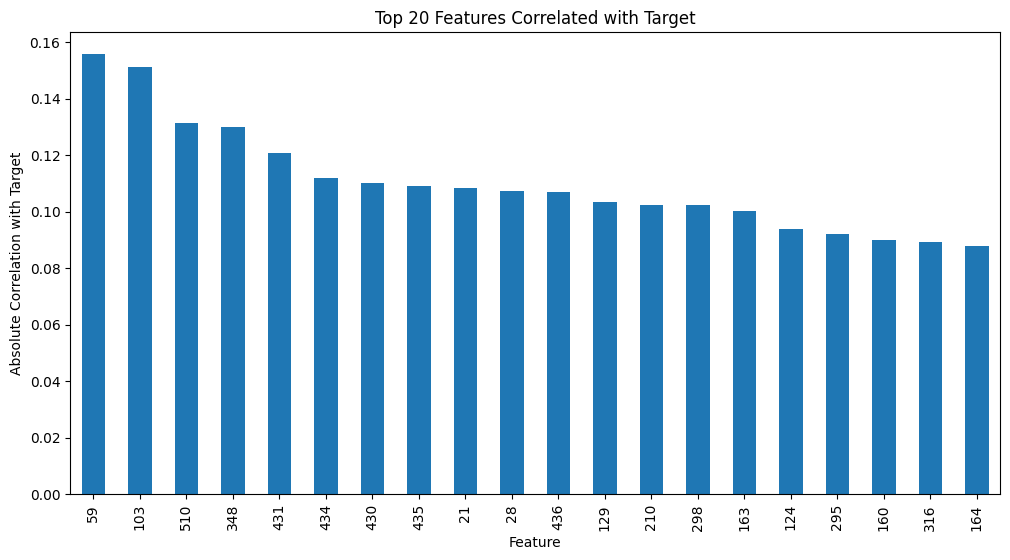

In [221]:
plt.figure(figsize=(12, 6))

top20_corr.plot(kind='bar')

plt.title("Top 20 Features Correlated with Target")
plt.xlabel("Feature")
plt.ylabel("Absolute Correlation with Target")

plt.xticks(rotation=90)

plt.show()

# **Temporal Analysis**

In [222]:
time_analysis_df = pd.DataFrame({
    "Time": pd.to_datetime(time_col),
    "Target": y
})

failures = time_analysis_df[time_analysis_df["Target"] == 1]

failures = failures.set_index("Time")

failures_per_week = failures.resample("W").size()

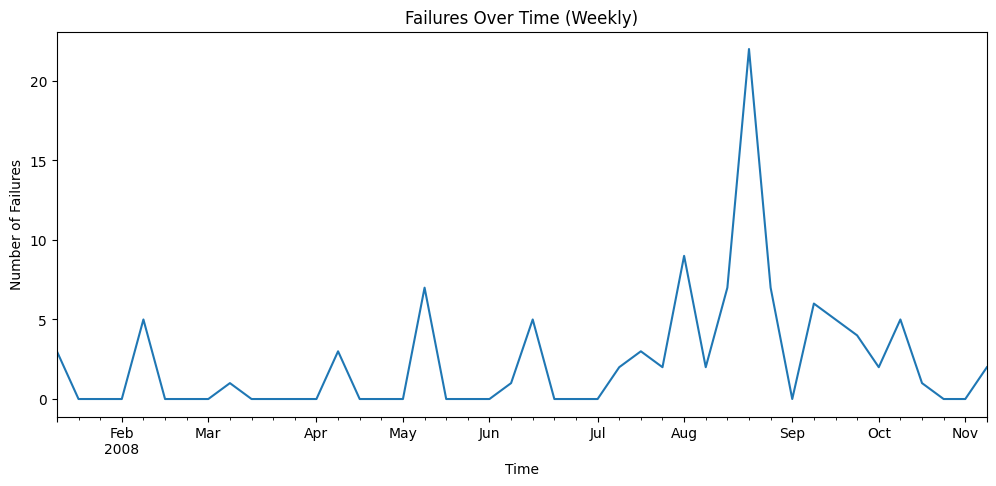

In [223]:
plt.figure(figsize=(12, 5))

failures_per_week.plot()

plt.title("Failures Over Time (Weekly)")
plt.xlabel("Time")
plt.ylabel("Number of Failures")

plt.show()

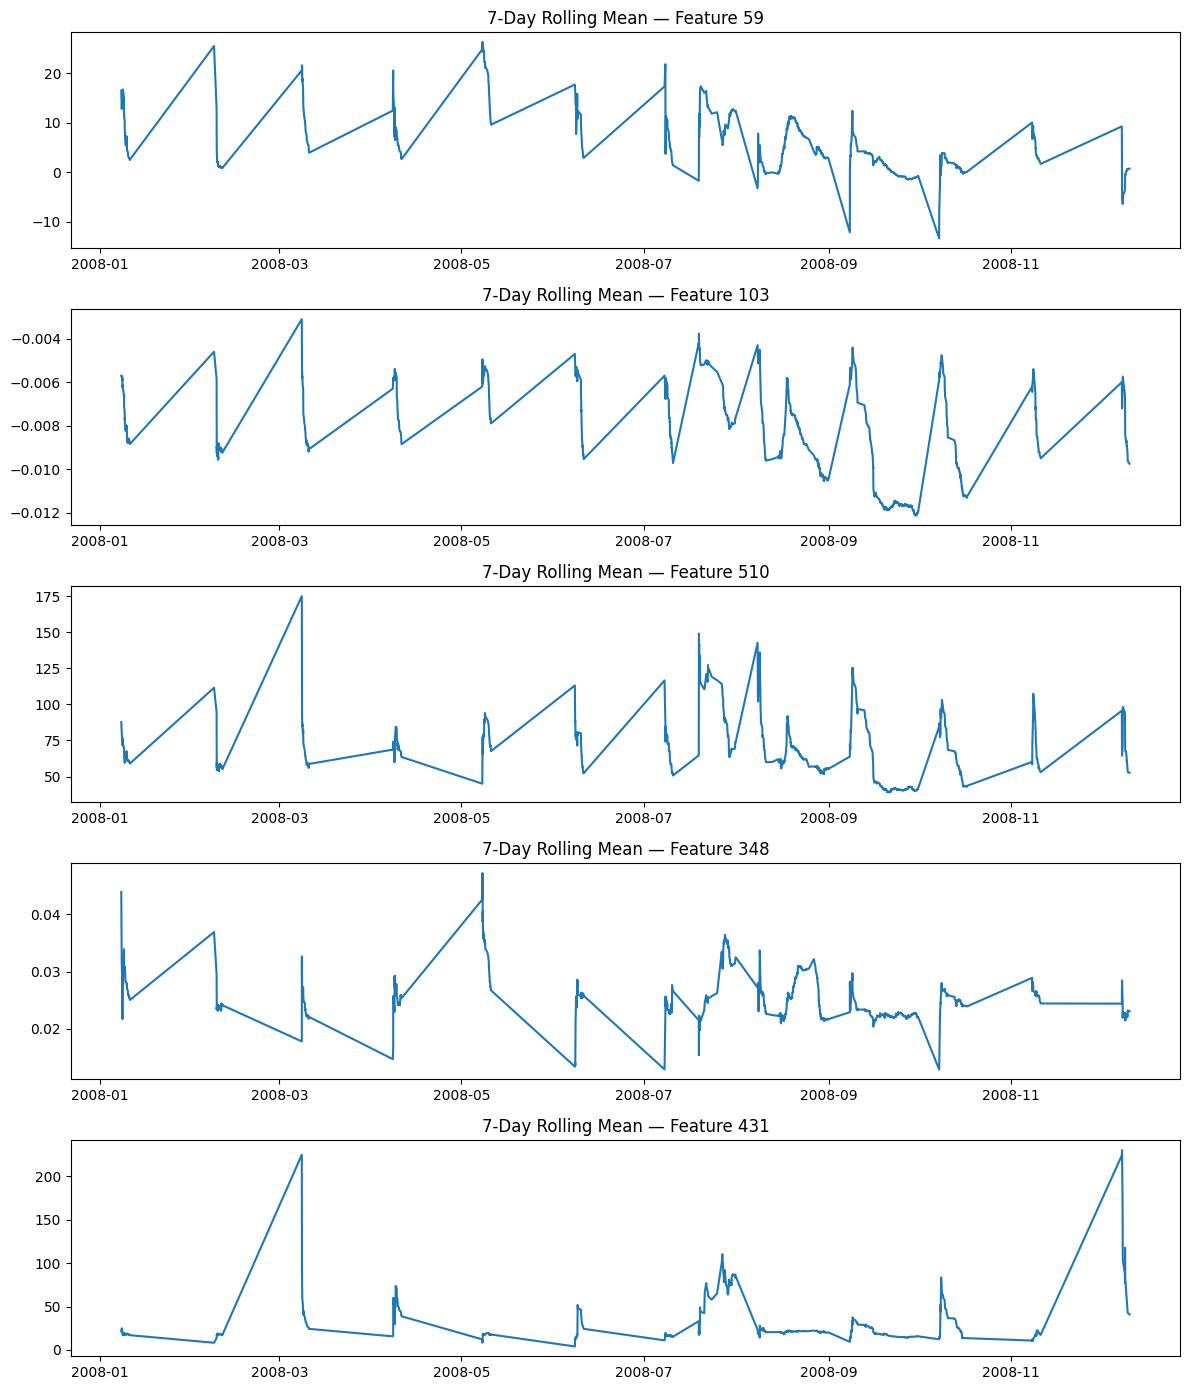

In [224]:
important_features = top20_corr.index[:5]

drift_df = X_clean[important_features].copy()
drift_df["Time"] = pd.to_datetime(time_col)

drift_df = drift_df.sort_values("Time")

drift_df = drift_df.set_index("Time")

fig, axes = plt.subplots(len(important_features), 1, figsize=(12, 14))

if len(important_features) == 1:
    axes = [axes]

for i, feature in enumerate(important_features):

    rolling_mean = drift_df[feature].rolling("7D").mean()

    axes[i].plot(rolling_mean)

    axes[i].set_title(f"7-Day Rolling Mean — Feature {feature}")

plt.tight_layout()
plt.show()

In [225]:
failure_times = pd.to_datetime(time_col[y == 1].sort_values())

failure_gaps = failure_times.diff().dropna()

failure_gaps_hours = failure_gaps.dt.total_seconds() / 3600

print("Failure Gap Statistics (Hours):")
print(failure_gaps_hours.describe())

Failure Gap Statistics (Hours):
count    103.000000
mean      71.475081
std      170.931356
min        0.050000
25%        2.175000
50%        8.666667
75%       39.450000
max      741.350000
Name: Time, dtype: float64


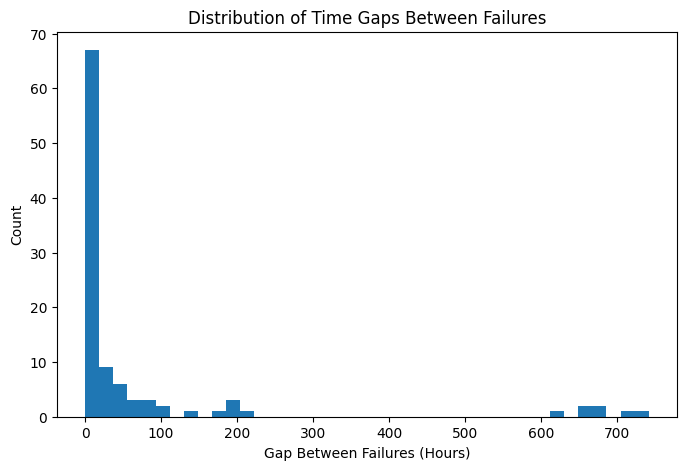

In [226]:
plt.figure(figsize=(8, 5))

plt.hist(failure_gaps_hours, bins=40)

plt.title("Distribution of Time Gaps Between Failures")
plt.xlabel("Gap Between Failures (Hours)")
plt.ylabel("Count")

plt.show()

# **Dimensionality Reduction**

PCA

In [227]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


X_numeric = X_clean.drop(columns=['Time'], errors='ignore')

imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X_numeric)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance)

components_80 = np.argmax(cumulative_variance >= 0.80) + 1
components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components for 80% variance:", components_80)
print("Components for 90% variance:", components_90)
print("Components for 95% variance:", components_95)

Components for 80% variance: 86
Components for 90% variance: 128
Components for 95% variance: 160


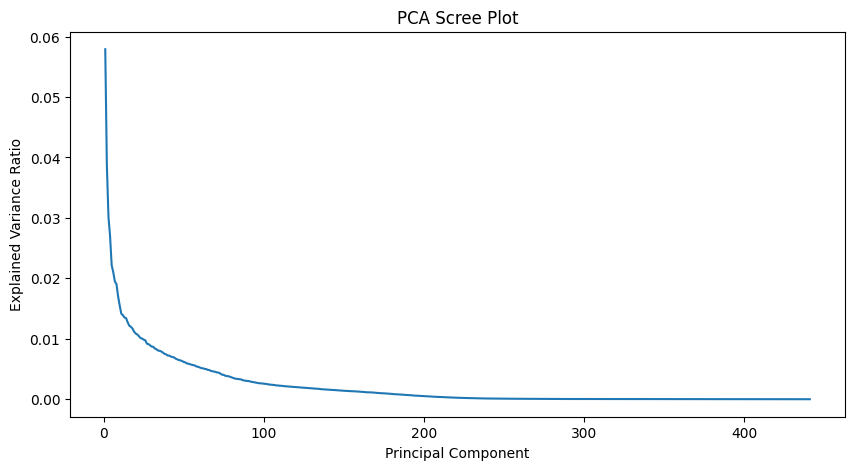

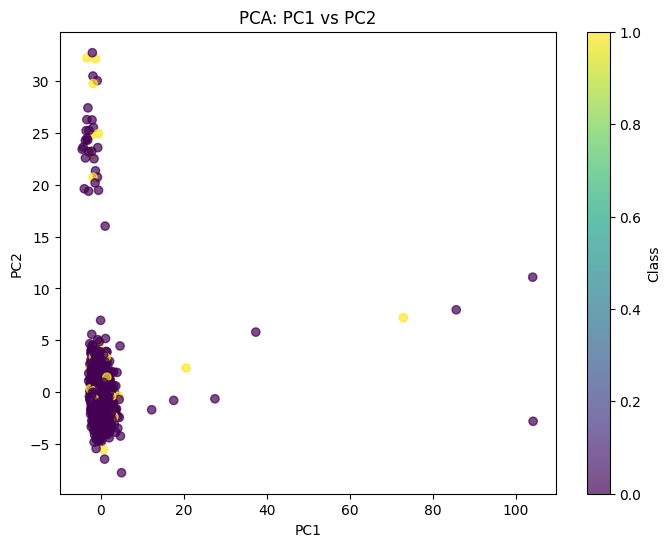

In [228]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance
)

plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.show()

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    alpha=0.7
)

plt.title("PCA: PC1 vs PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Class")

plt.show()

TSNE

In [229]:
from sklearn.manifold import TSNE

pca_50 = PCA(n_components=50)

X_pca_50 = pca_50.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca_50)

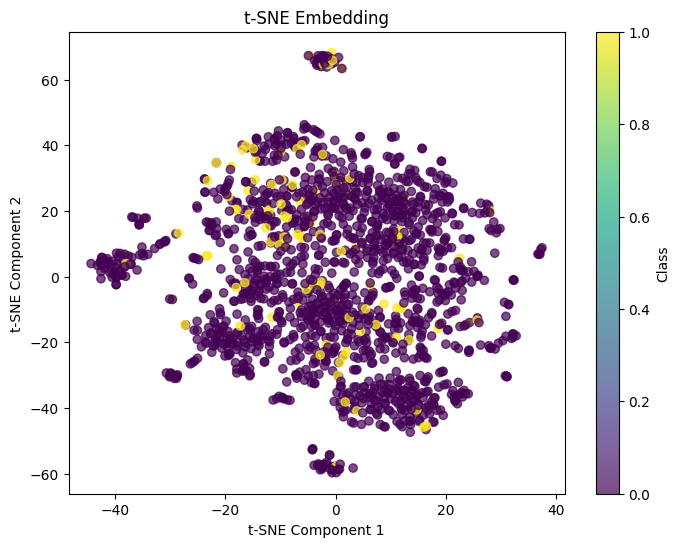

In [230]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    alpha=0.7
)

plt.title("t-SNE Embedding")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.colorbar(label="Class")

plt.show()

U-Map

In [231]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

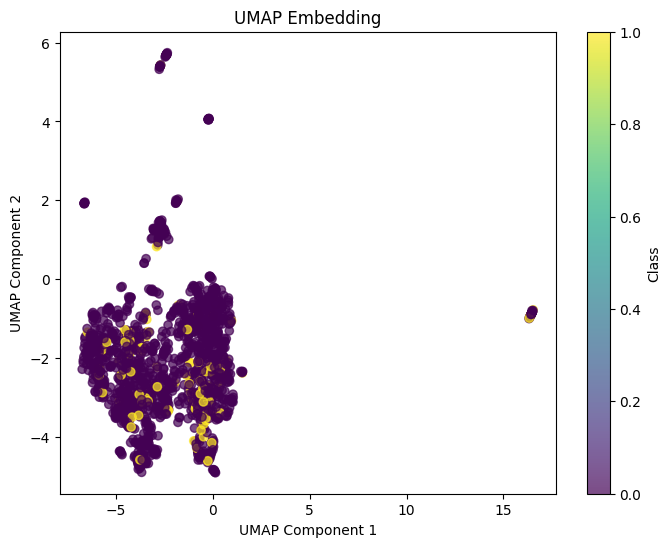

In [232]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y,
    alpha=0.7
)

plt.title("UMAP Embedding")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.colorbar(label="Class")

plt.show()

In [233]:
class_ratio = y.value_counts(normalize=True)

pass_ratio = class_ratio[0] * 100
fail_ratio = class_ratio[1] * 100

total_missing = X.isnull().sum().sum()
overall_missing_rate = X.isnull().mean().mean() * 100

summary_dict = {
    "Metric": [
        "Total Original Features",
        "Zero-Variance Features Dropped",
        "High-Missing Features Dropped (>50%)",
        "Remaining Features",
        "Total Missing Cells",
        "Overall Missing Rate (%)",
        "Pass Class Ratio (%)",
        "Fail Class Ratio (%)",
        "Statistically Significant Features",
        "Highly Correlated Feature Pairs (>0.9)"
    ],

    "Value": [
        X.shape[1],
        len(zero_variance_cols),
        len(high_missing_cols_list),
        X_clean.shape[1],
        total_missing,
        round(overall_missing_rate, 2),
        round(pass_ratio, 2),
        round(fail_ratio, 2),
        significant_count,
        len(high_corr_df)
    ]
}

summary_df = pd.DataFrame(summary_dict)

print(summary_df)

                                   Metric     Value
0                 Total Original Features    590.00
1          Zero-Variance Features Dropped    116.00
2    High-Missing Features Dropped (>50%)     32.00
3                      Remaining Features    442.00
4                     Total Missing Cells  41950.00
5                Overall Missing Rate (%)      4.54
6                    Pass Class Ratio (%)     93.36
7                    Fail Class Ratio (%)      6.64
8      Statistically Significant Features     17.00
9  Highly Correlated Feature Pairs (>0.9)    349.00


# **Model**

In [234]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

top_features = pval_df.head(50)['Feature'].tolist()
X_model = X_clean[top_features]

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_model)
scaler = StandardScaler()
X_sc  = scaler.fit_transform(X_imp)

X_res, y_res = SMOTE(random_state=42).fit_resample(X_sc, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42)

In [235]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, scale_pos_weight=13, random_state=42,
                                              eval_metric='logloss'),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    auc    = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'auc': auc, 'pred': y_pred}
    print(f"\n{'='*40}")
    print(f"{name}  —  AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Pass','Fail']))


Logistic Regression  —  AUC-ROC: 0.8227
              precision    recall  f1-score   support

        Pass       0.76      0.73      0.75       306
        Fail       0.72      0.75      0.74       280

    accuracy                           0.74       586
   macro avg       0.74      0.74      0.74       586
weighted avg       0.74      0.74      0.74       586


Random Forest  —  AUC-ROC: 0.9983
              precision    recall  f1-score   support

        Pass       1.00      0.97      0.98       306
        Fail       0.97      1.00      0.98       280

    accuracy                           0.98       586
   macro avg       0.98      0.98      0.98       586
weighted avg       0.98      0.98      0.98       586


XGBoost  —  AUC-ROC: 0.9979
              precision    recall  f1-score   support

        Pass       1.00      0.88      0.94       306
        Fail       0.89      1.00      0.94       280

    accuracy                           0.94       586
   macro avg       0.94

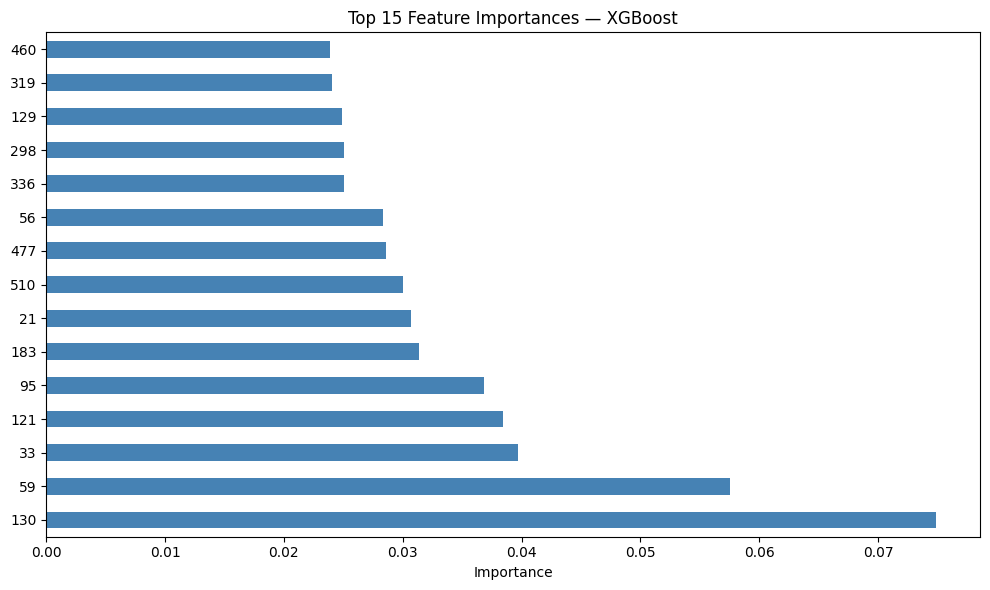

In [236]:
best = results['XGBoost']['model']
feat_imp = pd.Series(best.feature_importances_, index=top_features)
feat_imp.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Top 15 Feature Importances — XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()